# V6 Multitask Training
Trains on the filtered, cleaned dataset from `00_data_filter_and_analysis.ipynb`.

**What changed from V5:**
- Loads from `train_filtered.csv` / `val_filtered.csv` / `test_filtered.csv` — no Tobi
- Body-only text (no subject, no agent replies)
- Priority labels re-derived from signal rules aligned with Priority_Escalation_Criteria.txt
- Class-weighted loss to handle imbalance (Customer Service=237, Technical=700)
- Weighted loss ratio: dept=1.0, priority=0.3 (priority head is harder with 3 classes)
- More epochs (6) with warmup and cosine LR schedule
- Per-class F1 printed after eval so you can see which classes are weak

## 0. Imports

In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from datasets import Dataset, DatasetDict, ClassLabel, Features, Value
from transformers import (
    AutoTokenizer, AutoModel,
    TrainingArguments, Trainer,
    get_cosine_schedule_with_warmup
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load Filtered CSVs
These come from `00_data_filter_and_analysis.ipynb`. Point `DATA_DIR` at wherever you saved them.

In [2]:
# ── Point this at your outputs folder ─────────────────────────────────
DATA_DIR = './outputs'   # change if needed

df_train = pd.read_csv(f'{DATA_DIR}/train_filtered.csv')
df_val   = pd.read_csv(f'{DATA_DIR}/val_filtered.csv')
df_test  = pd.read_csv(f'{DATA_DIR}/test_filtered.csv')

print(f'Train : {len(df_train):,}')
print(f'Val   : {len(df_val):,}')
print(f'Test  : {len(df_test):,}')
print(f'\nTrain class distribution:')
print(df_train['queue'].value_counts())
print(f'\nTrain priority distribution:')
print(df_train['priority'].value_counts())

Train : 2,668
Val   : 572
Test  : 572

Train class distribution:
queue
Technical & IT Support             490
Returns and Exchanges              490
Billing and Payments               476
Sales and Pre-Sales                444
Human Resources                    277
General Inquiry                    216
Customer Service                   166
Service Outages and Maintenance    109
Name: count, dtype: int64

Train priority distribution:
priority
medium    1908
high       718
low         42
Name: count, dtype: int64


## 2. Light cleaning on loaded text
The CSVs are already clean from the filter notebook, but we strip any remaining whitespace issues.

In [3]:
def final_clean(text):
    """Final normalisation pass — text is already clean from filter notebook."""
    text = str(text)
    text = text.replace('\\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

for df in [df_train, df_val, df_test]:
    df['text']     = df['text'].apply(final_clean)
    df['queue']    = df['queue'].str.strip()
    df['priority'] = df['priority'].str.lower().str.strip()

# Drop any rows with empty text after cleaning
for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    before = len(df)
    mask = df['text'].str.split().str.len() >= 8
    df.drop(df[~mask].index, inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'{name}: {before} → {len(df)} (dropped {before-len(df)} short)')

print('\nSample texts after cleaning:')
for _, row in df_train.sample(3, random_state=SEED).iterrows():
    print(f'  [{row["queue"]}] {row["text"][:150]!r}')
    print()

train: 2668 → 2668 (dropped 0 short)
val: 572 → 572 (dropped 0 short)
test: 572 → 572 (dropped 0 short)

Sample texts after cleaning:
  [Human Resources] 'I am seeking help with digital marketing initiatives. Our marketing agency is having difficulty boosting brand growth through digital strategies. Desp'

  [Sales and Pre-Sales] 'I am requesting comprehensive information on integration options between QuickBooks Online, Oracle Database 19c, and our SaaS project management platf'

  [Returns and Exchanges] 'team. Our present stock tracking and management framework appears to be inadequate, causing orders to go unfilled. Despite conducting manual inventory'



## 3. Encode Labels

In [4]:
queue_encoder    = LabelEncoder()
priority_encoder = LabelEncoder()

# Fit on train only — val/test use same mapping
queue_encoder.fit(df_train['queue'])
priority_encoder.fit(df_train['priority'])

for df in [df_train, df_val, df_test]:
    df['queue_id']    = queue_encoder.transform(df['queue'])
    df['priority_id'] = priority_encoder.transform(df['priority'])

print(f'Queue classes ({len(queue_encoder.classes_)}): {list(queue_encoder.classes_)}')
print(f'Priority classes ({len(priority_encoder.classes_)}): {list(priority_encoder.classes_)}')

Queue classes (8): ['Billing and Payments', 'Customer Service', 'General Inquiry', 'Human Resources', 'Returns and Exchanges', 'Sales and Pre-Sales', 'Service Outages and Maintenance', 'Technical & IT Support']
Priority classes (3): ['high', 'low', 'medium']


## 4. Compute Class Weights for Balanced Loss
Addresses the imbalance between classes like Customer Service (237) vs Technical (700).

In [5]:
from sklearn.utils.class_weight import compute_class_weight

queue_weights = compute_class_weight(
    class_weight='balanced',
    classes=queue_encoder.classes_,
    y=df_train['queue']
)
priority_weights = compute_class_weight(
    class_weight='balanced',
    classes=priority_encoder.classes_,
    y=df_train['priority']
)

queue_weights_tensor    = torch.tensor(queue_weights,    dtype=torch.float).to(device)
priority_weights_tensor = torch.tensor(priority_weights, dtype=torch.float).to(device)

print('Queue weights:')
for cls, w in zip(queue_encoder.classes_, queue_weights):
    count = (df_train['queue'] == cls).sum()
    print(f'  {cls:<40} count={count:>4}  weight={w:.3f}')

print('\nPriority weights:')
for cls, w in zip(priority_encoder.classes_, priority_weights):
    count = (df_train['priority'] == cls).sum()
    print(f'  {cls:<10} count={count:>4}  weight={w:.3f}')

Queue weights:
  Billing and Payments                     count= 476  weight=0.701
  Customer Service                         count= 166  weight=2.009
  General Inquiry                          count= 216  weight=1.544
  Human Resources                          count= 277  weight=1.204
  Returns and Exchanges                    count= 490  weight=0.681
  Sales and Pre-Sales                      count= 444  weight=0.751
  Service Outages and Maintenance          count= 109  weight=3.060
  Technical & IT Support                   count= 490  weight=0.681

Priority weights:
  high       count= 718  weight=1.239
  low        count=  42  weight=21.175
  medium     count=1908  weight=0.466


## 5. Build HuggingFace Datasets

In [6]:
queue_class_label = ClassLabel(
    num_classes=len(queue_encoder.classes_),
    names=list(queue_encoder.classes_)
)

features = Features({
    'text':       Value('string'),
    'queue_id':   queue_class_label,
    'priority_id': Value('int64'),
})

COLS = ['text', 'queue_id', 'priority_id']

hf_train = Dataset.from_pandas(df_train[COLS].reset_index(drop=True), features=features)
hf_val   = Dataset.from_pandas(df_val[COLS].reset_index(drop=True),   features=features)
hf_test  = Dataset.from_pandas(df_test[COLS].reset_index(drop=True),  features=features)

dataset = DatasetDict({
    'train':      hf_train,
    'validation': hf_val,
    'test':       hf_test,
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'queue_id', 'priority_id'],
        num_rows: 2668
    })
    validation: Dataset({
        features: ['text', 'queue_id', 'priority_id'],
        num_rows: 572
    })
    test: Dataset({
        features: ['text', 'queue_id', 'priority_id'],
        num_rows: 572
    })
})


## 6. Tokenise

In [7]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=128   # reduced from 256 — median ticket is ~60 words, saves memory
    )

dataset = dataset.map(tokenize, batched=True)

def combine_labels(example):
    example['labels'] = [example['queue_id'], example['priority_id']]
    return example

dataset = dataset.map(combine_labels)
dataset.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'labels']
)

print('Tokenisation complete.')
print(dataset)

Map:   0%|          | 0/2668 [00:00<?, ? examples/s]

Map:   0%|          | 0/572 [00:00<?, ? examples/s]

Map:   0%|          | 0/572 [00:00<?, ? examples/s]

Map:   0%|          | 0/2668 [00:00<?, ? examples/s]

Map:   0%|          | 0/572 [00:00<?, ? examples/s]

Map:   0%|          | 0/572 [00:00<?, ? examples/s]

Tokenisation complete.
DatasetDict({
    train: Dataset({
        features: ['text', 'queue_id', 'priority_id', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2668
    })
    validation: Dataset({
        features: ['text', 'queue_id', 'priority_id', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 572
    })
    test: Dataset({
        features: ['text', 'queue_id', 'priority_id', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 572
    })
})


## 7. Model — MultiTask DistilBERT with Weighted Loss

In [8]:
class MultiTaskModel(nn.Module):
    def __init__(self, model_name, num_queue_labels, num_priority_labels,
                 queue_weights=None, priority_weights=None):
        super().__init__()
        self.encoder              = AutoModel.from_pretrained(model_name)
        hidden_size               = self.encoder.config.hidden_size
        self.queue_classifier     = nn.Linear(hidden_size, num_queue_labels)
        self.priority_classifier  = nn.Linear(hidden_size, num_priority_labels)
        self.queue_weights        = queue_weights       # class weights tensor
        self.priority_weights     = priority_weights

    def forward(self, input_ids, attention_mask, labels=None):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0]   # [CLS] token

        q_logits = self.queue_classifier(pooled)
        p_logits = self.priority_classifier(pooled)

        loss = None
        if labels is not None:
            q_labels = labels[:, 0]
            p_labels = labels[:, 1]

            # Weighted CrossEntropy for class imbalance
            q_loss = F.cross_entropy(q_logits, q_labels, weight=self.queue_weights)
            p_loss = F.cross_entropy(p_logits, p_labels, weight=self.priority_weights)

            # Dept loss dominates — priority is harder and has fewer classes
            # 0.3 weight for priority keeps it from overwhelming dept learning
            loss = q_loss + 0.3 * p_loss

        return {'loss': loss, 'logits': (q_logits, p_logits)}


model = MultiTaskModel(
    'distilbert-base-uncased',
    num_queue_labels    = len(queue_encoder.classes_),
    num_priority_labels = len(priority_encoder.classes_),
    queue_weights       = queue_weights_tensor,
    priority_weights    = priority_weights_tensor,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable:,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params    : 66,371,339
Trainable params: 66,371,339


## 8. Metrics

In [9]:
def compute_metrics(eval_pred):
    (q_logits, p_logits), labels = eval_pred

    q_preds = np.argmax(q_logits, axis=1)
    p_preds = np.argmax(p_logits, axis=1)
    q_labels = labels[:, 0]
    p_labels = labels[:, 1]

    q_f1_per_class = f1_score(q_labels, q_preds, average=None,
                               labels=list(range(len(queue_encoder.classes_))))

    metrics = {
        'queue_accuracy':    accuracy_score(q_labels, q_preds),
        'queue_macro_f1':    f1_score(q_labels, q_preds, average='macro'),
        'queue_weighted_f1': f1_score(q_labels, q_preds, average='weighted'),
        'priority_accuracy': accuracy_score(p_labels, p_preds),
        'priority_macro_f1': f1_score(p_labels, p_preds, average='macro'),
    }

    # Per-class F1 so we can see which depts are weak
    for cls_name, f1 in zip(queue_encoder.classes_, q_f1_per_class):
        safe_name = cls_name.replace(' ', '_').replace('&', 'and')
        metrics[f'f1_{safe_name}'] = round(float(f1), 4)

    return metrics

## 9. Train

In [12]:
OUTPUT_DIR = './v6_multitask_model'

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = 6,          # more epochs — smaller dataset
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 3e-5,       # slightly higher than v5 for small dataset
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,        # 10% warmup steps
    lr_scheduler_type           = 'cosine',   # cosine decay instead of linear
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'queue_macro_f1',
    greater_is_better           = True,
    fp16                        = torch.cuda.is_available(),  # mixed precision on GPU
    dataloader_num_workers      = 0,
    seed                        = SEED,
    logging_steps               = 50,
    report_to                   = 'none',
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = dataset['train'],
    eval_dataset    = dataset['validation'],
    processing_class= tokenizer,
    compute_metrics = compute_metrics,
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Queue Accuracy,Queue Macro F1,Queue Weighted F1,Priority Accuracy,Priority Macro F1,F1 Billing And Payments,F1 Customer Service,F1 General Inquiry,F1 Human Resources,F1 Returns And Exchanges,F1 Sales And Pre-sales,F1 Service Outages And Maintenance,F1 Technical And It Support
1,1.630578,1.524672,0.538462,0.444588,0.506963,0.809441,0.520727,0.990300,0.000000,0.219800,0.333300,0.300000,0.483400,0.586200,0.643700
2,1.217985,1.276136,0.603147,0.559233,0.602390,0.814685,0.627497,0.995100,0.296300,0.333300,0.588200,0.460700,0.478700,0.619000,0.702500
3,0.823629,1.187338,0.660839,0.622617,0.663864,0.896853,0.693728,0.995100,0.354200,0.500000,0.573300,0.559500,0.605700,0.666700,0.726500
4,0.570030,1.092585,0.694056,0.669793,0.697621,0.895105,0.700615,0.995100,0.461500,0.551000,0.682500,0.571400,0.674000,0.717900,0.704800
5,0.363322,1.139287,0.730769,0.699938,0.727789,0.905594,0.714695,0.995100,0.459000,0.594100,0.710700,0.605100,0.701000,0.769200,0.765200
6,0.320281,1.134100,0.732517,0.699118,0.730288,0.910839,0.723134,0.995100,0.444400,0.626300,0.705900,0.624400,0.691500,0.736800,0.768600


TrainOutput(global_step=1002, training_loss=0.8954334856269365, metrics={'train_runtime': 69.0677, 'train_samples_per_second': 231.773, 'train_steps_per_second': 14.507, 'total_flos': 0.0, 'train_loss': 0.8954334856269365, 'epoch': 6.0})

## 10. Evaluate on Test Set

In [13]:
predictions = trainer.predict(dataset['test'])
print('\n=== TEST SET METRICS ===')
for k, v in predictions.metrics.items():
    print(f'  {k:<40} {v:.4f}')


=== TEST SET METRICS ===
  test_loss                                0.9186
  test_queue_accuracy                      0.7517
  test_queue_macro_f1                      0.7269
  test_queue_weighted_f1                   0.7513
  test_priority_accuracy                   0.8846
  test_priority_macro_f1                   0.7100
  test_f1_Billing_and_Payments             0.9901
  test_f1_Customer_Service                 0.6027
  test_f1_General_Inquiry                  0.6392
  test_f1_Human_Resources                  0.6500
  test_f1_Returns_and_Exchanges            0.6774
  test_f1_Sales_and_Pre-Sales              0.7143
  test_f1_Service_Outages_and_Maintenance  0.7586
  test_f1_Technical_and_IT_Support         0.7830
  test_runtime                             0.6381
  test_samples_per_second                  896.4030
  test_steps_per_second                    28.2080


## 11. Confusion Matrices + Per-Class Report


=== DEPARTMENT CLASSIFICATION REPORT ===
                                 precision    recall  f1-score   support

           Billing and Payments      1.000     0.980     0.990       102
               Customer Service      0.595     0.611     0.603        36
                General Inquiry      0.608     0.674     0.639        46
                Human Resources      0.650     0.650     0.650        60
          Returns and Exchanges      0.778     0.600     0.677       105
            Sales and Pre-Sales      0.693     0.737     0.714        95
Service Outages and Maintenance      0.629     0.957     0.759        23
         Technical & IT Support      0.776     0.790     0.783       105

                       accuracy                          0.752       572
                      macro avg      0.716     0.750     0.727       572
                   weighted avg      0.758     0.752     0.751       572


=== PRIORITY CLASSIFICATION REPORT ===
              precision    recall  f1-s

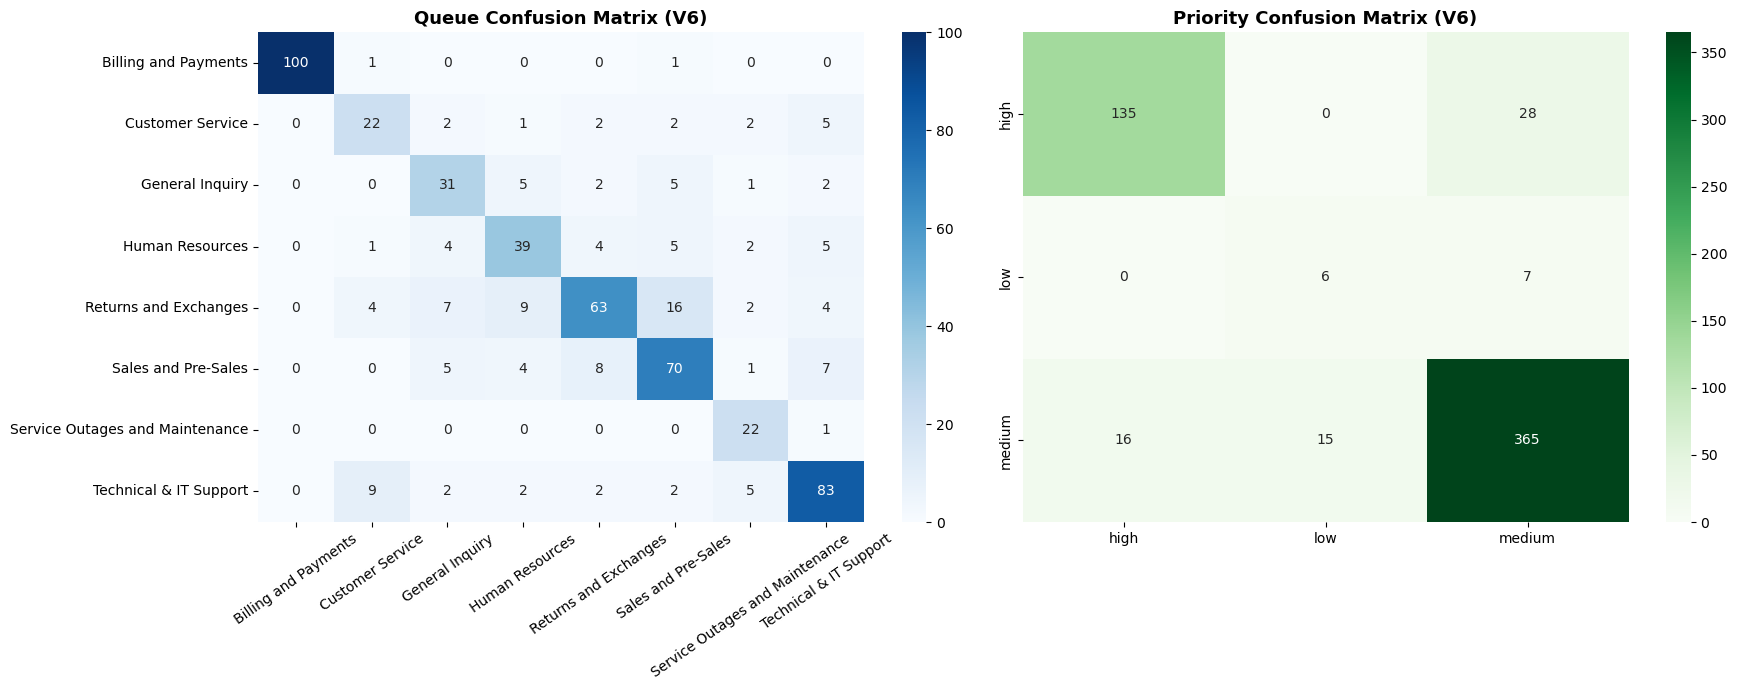

Saved → outputs/v6_confusion_matrices.png


In [14]:
q_logits, p_logits = predictions.predictions
labels             = predictions.label_ids

q_preds  = np.argmax(q_logits,  axis=1)
p_preds  = np.argmax(p_logits,  axis=1)
q_labels = labels[:, 0]
p_labels = labels[:, 1]

# ── Full classification report ─────────────────────────────────────────
print('\n=== DEPARTMENT CLASSIFICATION REPORT ===')
print(classification_report(
    q_labels, q_preds,
    target_names=queue_encoder.classes_,
    digits=3
))

print('\n=== PRIORITY CLASSIFICATION REPORT ===')
print(classification_report(
    p_labels, p_preds,
    target_names=priority_encoder.classes_,
    digits=3
))

# ── Confusion matrices ─────────────────────────────────────────────────
cm_q = confusion_matrix(q_labels, q_preds)
cm_p = confusion_matrix(p_labels, p_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_q, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=queue_encoder.classes_,
            yticklabels=queue_encoder.classes_)
axes[0].set_title('Queue Confusion Matrix (V6)', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(cm_p, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=priority_encoder.classes_,
            yticklabels=priority_encoder.classes_)
axes[1].set_title('Priority Confusion Matrix (V6)', fontsize=13, fontweight='bold')

plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/v6_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved → outputs/v6_confusion_matrices.png')

## 12. Confidence Distribution — Understanding the Gate
Shows at what confidence level the transformer is correct.
Use this to calibrate the confidence gate thresholds in `router.py`.

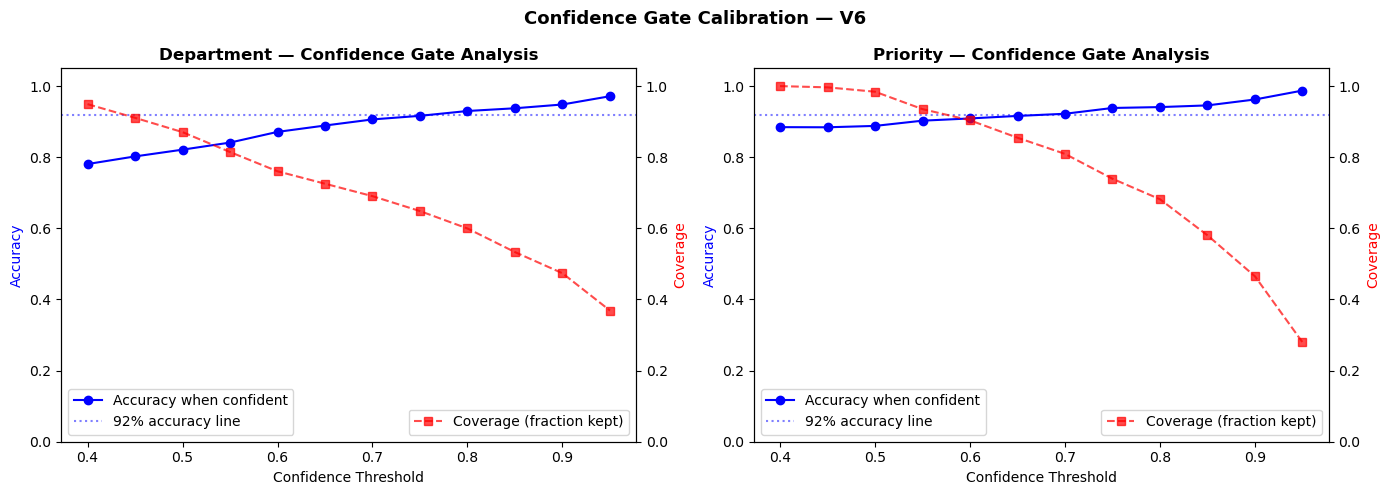


Recommended thresholds (accuracy ≥ 0.92):
  Dept threshold ≥ 0.70  →  accuracy=0.922  coverage=0.809


In [15]:
import torch.nn.functional as F_torch

q_probs  = F_torch.softmax(torch.tensor(q_logits),  dim=1).numpy()
p_probs  = F_torch.softmax(torch.tensor(p_logits),  dim=1).numpy()

q_max_conf = q_probs.max(axis=1)
p_max_conf = p_probs.max(axis=1)
q_correct  = (q_preds == q_labels)
p_correct  = (p_preds == p_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# For each threshold, what fraction of confident predictions are correct?
thresholds = np.arange(0.4, 1.0, 0.05)

for ax, confs, correct, title in [
    (axes[0], q_max_conf, q_correct, 'Department'),
    (axes[1], p_max_conf, p_correct, 'Priority'),
]:
    accuracies = []
    coverages  = []
    for t in thresholds:
        mask = confs >= t
        if mask.sum() == 0:
            accuracies.append(np.nan)
            coverages.append(0)
        else:
            accuracies.append(correct[mask].mean())
            coverages.append(mask.mean())

    ax2 = ax.twinx()
    ax.plot(thresholds, accuracies, 'b-o', label='Accuracy when confident')
    ax2.plot(thresholds, coverages, 'r--s', label='Coverage (fraction kept)', alpha=0.7)
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Accuracy', color='blue')
    ax2.set_ylabel('Coverage', color='red')
    ax.set_title(f'{title} — Confidence Gate Analysis', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax2.set_ylim(0, 1.05)
    ax.axhline(0.92, color='blue', linestyle=':', alpha=0.5, label='92% accuracy line')
    ax.legend(loc='lower left')
    ax2.legend(loc='lower right')

plt.suptitle('Confidence Gate Calibration — V6', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/v6_confidence_gate.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nRecommended thresholds (accuracy ≥ 0.92):')
for t, acc, cov in zip(thresholds, accuracies, coverages):
    if acc is not None and not np.isnan(acc) and acc >= 0.92:
        print(f'  Dept threshold ≥ {t:.2f}  →  accuracy={acc:.3f}  coverage={cov:.3f}')
        break

## 13. Save Model

In [16]:
SAVE_DIR = './saved_v6_multitask'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save encoder backbone + tokenizer (HF format)
model.encoder.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save classification heads separately
torch.save({
    'queue_classifier':    model.queue_classifier.state_dict(),
    'priority_classifier': model.priority_classifier.state_dict(),
}, os.path.join(SAVE_DIR, 'heads.pt'))

# Save label encoders
joblib.dump(queue_encoder,    os.path.join(SAVE_DIR, 'queue_encoder.pkl'))
joblib.dump(priority_encoder, os.path.join(SAVE_DIR, 'priority_encoder.pkl'))

print(f'Model saved to {SAVE_DIR}/')
print('Files:')
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(os.path.join(SAVE_DIR, f))
    print(f'  {f:<40} {size/1024:.1f} KB')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./saved_v6_multitask/
Files:
  config.json                              0.6 KB
  heads.pt                                 34.9 KB
  model.safetensors                        259240.8 KB
  priority_encoder.pkl                     0.5 KB
  queue_encoder.pkl                        0.6 KB
  tokenizer.json                           695.0 KB
  tokenizer_config.json                    0.3 KB


## 14. Quick Inference Test
Sanity check — same test tickets from V5 so you can compare results directly.

In [18]:
def predict(text: str) -> dict:
    """Run inference on a single raw ticket text."""
    # Light clean
    text = re.sub(r'\s+', ' ', str(text).replace('\\n', ' ')).strip()

    inputs = tokenizer(
        text, return_tensors='pt',
        truncation=True, padding=True, max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()
          if k != 'token_type_ids'}

    with torch.no_grad():
        out = model(**inputs)
        q_logits, p_logits = out['logits']
        q_probs = F.softmax(q_logits, dim=1)[0]
        p_probs = F.softmax(p_logits, dim=1)[0]

    q_id   = q_probs.argmax().item()
    p_id   = p_probs.argmax().item()
    top3   = q_probs.topk(3)

    return {
        'queue':          queue_encoder.classes_[q_id],
        'queue_conf':     round(q_probs[q_id].item(), 4),
        'priority':       priority_encoder.classes_[p_id],
        'priority_conf':  round(p_probs[p_id].item(), 4),
        'top3': [
            {'dept': queue_encoder.classes_[i], 'prob': round(q_probs[i].item(), 4)}
            for i in top3.indices.tolist()
        ],
    }


TEST_TICKETS = [
    ("Technical & IT Support", "high",
     "Our production server keeps crashing after the recent update. The database connection "
     "fails and users can't access the dashboard. Multiple departments affected, needs urgent fix."),

    ("Billing and Payments", "medium",
     "I was charged twice for my subscription renewal this month. Please check invoice #4521 "
     "and process a refund for the duplicate payment."),

    ("Sales and Pre-Sales", "low",
     "Could you send me information about your premium plan features and pricing? "
     "Looking to upgrade before Q2."),

    ("Human Resources", "low",
     "I'm having trouble accessing the employee portal to submit my leave request. "
     "The system doesn't recognise my credentials."),

    ("Returns and Exchanges", "medium",
     "I received the wrong item in my order. The packing slip shows the right product "
     "but the box contains something else. How do I return it?"),

    ("Service Outages and Maintenance", "high",
     "Your platform has been completely unavailable for 3 hours. All our users are affected "
     "and we're losing revenue. Is there a known outage?"),
]

print(f'{"Expected Dept":<40} {"Expected Pri":<10} {"Predicted Dept":<40} {"Conf":<6} {"Pri":<8} {"Conf"}')
print('-' * 120)
for expected_dept, expected_pri, ticket in TEST_TICKETS:
    result = predict(ticket)
    dept_ok = '✓' if result['queue'] == expected_dept else '✗'
    pri_ok  = '✓' if result['priority'] == expected_pri else '~'
    print(f"{dept_ok} {expected_dept:<38} {expected_pri:<10} "
          f"{result['queue']:<40} {result['queue_conf']:<6.3f} "
          f"{result['priority']:<8} {result['priority_conf']:.3f} {pri_ok}")

Expected Dept                            Expected Pri Predicted Dept                           Conf   Pri      Conf
------------------------------------------------------------------------------------------------------------------------
✗ Technical & IT Support                 high       Human Resources                          0.572  high     0.766 ✓
✓ Billing and Payments                   medium     Billing and Payments                     0.992  medium   0.958 ✓
✓ Sales and Pre-Sales                    low        Sales and Pre-Sales                      0.783  medium   0.933 ~
✓ Human Resources                        low        Human Resources                          0.992  medium   0.547 ~
✓ Returns and Exchanges                  medium     Returns and Exchanges                    0.928  medium   0.903 ✓
✓ Service Outages and Maintenance        high       Service Outages and Maintenance          0.954  medium   0.815 ~


## 15. Recommended Gate Thresholds for router.py
Based on the confidence gate analysis above, these are the per-class thresholds
to use in router.py. Classes with less training data get lower thresholds
so RAG activates more often for them.

In [19]:
# Run after training to see per-class confidence on test set
# These inform DEPT_THRESHOLDS in router.py

print('Per-class confidence analysis on test set:')
print(f'{"Department":<40} {"Train N":<8} {"Test Acc":<10} {"Median Conf":<12} {"Suggested Threshold"}')
print('-' * 90)

train_counts = df_train['queue'].value_counts()

for cls_idx, cls_name in enumerate(queue_encoder.classes_):
    mask = q_labels == cls_idx
    if mask.sum() == 0:
        continue
    cls_acc      = (q_preds[mask] == q_labels[mask]).mean()
    cls_conf     = q_max_conf[mask].mean()
    train_n      = train_counts.get(cls_name, 0)

    # Suggested threshold: lower for small classes, higher for large ones
    # Never below 0.55 (random-ish) or above 0.88
    if train_n < 200:
        suggested = 0.60
    elif train_n < 350:
        suggested = 0.65
    elif train_n < 500:
        suggested = 0.72
    else:
        suggested = 0.80

    print(f'{cls_name:<40} {train_n:<8} {cls_acc:<10.3f} {cls_conf:<12.3f} {suggested}')

print()
print('Copy these into router.py as DEPT_THRESHOLDS = {...}')

Per-class confidence analysis on test set:
Department                               Train N  Test Acc   Median Conf  Suggested Threshold
------------------------------------------------------------------------------------------
Billing and Payments                     476      0.980      0.974        0.72
Customer Service                         166      0.611      0.756        0.6
General Inquiry                          216      0.674      0.669        0.65
Human Resources                          277      0.650      0.753        0.65
Returns and Exchanges                    490      0.600      0.692        0.72
Sales and Pre-Sales                      444      0.737      0.739        0.72
Service Outages and Maintenance          109      0.957      0.944        0.6
Technical & IT Support                   490      0.790      0.830        0.72

Copy these into router.py as DEPT_THRESHOLDS = {...}


In [21]:
import os
from dotenv import load_dotenv

load_dotenv("secrets.env")  # adjust path to wherever your secrets.env is
HF_TOKEN = os.getenv("HF_TOKEN")    # whatever the variable is named in your file

print(f"Token loaded: {HF_TOKEN[:8]}...")  # prints first 8 chars to confirm it loaded

Token loaded: hf_nqjhQ...


In [22]:
from huggingface_hub import HfApi
import os

api = HfApi()
REPO_ID = "Nethra19/multitask-ticket-model-v6"
HF_TOKEN = os.getenv("HF_TOKEN") 
SAVE_DIR = "./saved_v6_multitask"

# Upload every file in the save directory
for filename in os.listdir(SAVE_DIR):
    local_path = os.path.join(SAVE_DIR, filename)
    print(f"Uploading {filename}...")
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=filename,
        repo_id=REPO_ID,
        repo_type="model",
        token=HF_TOKEN,
    )
    print(f"  ✓ {filename}")

print("\nAll files uploaded.")
print(f"View at: https://huggingface.co/{REPO_ID}")

Uploading config.json...


No files have been modified since last commit. Skipping to prevent empty commit.


  ✓ config.json
Uploading heads.pt...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


  ✓ queue_encoder.pkl
Uploading tokenizer.json...


No files have been modified since last commit. Skipping to prevent empty commit.


  ✓ tokenizer.json
Uploading tokenizer_config.json...
  ✓ tokenizer_config.json

All files uploaded.
View at: https://huggingface.co/Nethra19/multitask-ticket-model-v6
